In [1]:
import os
os.environ["USE_TF"] = "0"
os.environ["USE_TORCH"] = "1"

# Import Libraries
import pandas as pd
import numpy as np
import re
import string
import warnings
warnings.filterwarnings('ignore')

# NLP Libraries
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

# Download NLTK data
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

# ML & Deep Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

# PyTorch & Transformers
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import DistilBertTokenizer, DistilBertForSequenceClassification, get_linear_schedule_with_warmup
from torch.optim import AdamW

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Victus\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\Victus\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Victus\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Victus\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\Victus\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


Using device: cuda


## 1. Load Dataset

In [2]:
# Load dataset
df = pd.read_csv('../data/dataset.csv')

# Display basic info
print("Dataset Shape:", df.shape)
print("\nDataset Info:")
print(df.info())
print("\nFirst 5 rows:")
df.head()

Dataset Shape: (12000, 3)

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 3 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   ticket_description  12000 non-null  object
 1   category            12000 non-null  object
 2   priority            12000 non-null  object
dtypes: object(3)
memory usage: 281.4+ KB
None

First 5 rows:


,ticket_description,category,priority
0,Network outage reported during peak working ho...,Network,Low
1,Cannot connect to WiFi network on the office l...,Network,Low
2,Network outage reported affecting critical bus...,Network,Low
3,Internet connection is very slow since this mo...,Network,Low
4,LAN connection is not detected reported by sev...,Network,Low


Category Distribution:
category
Network     3000
Software    3000
Hardware    3000
Access      3000
Name: count, dtype: int64

Priority Distribution:
priority
Low       5361
Medium    4203
High      2436
Name: count, dtype: int64


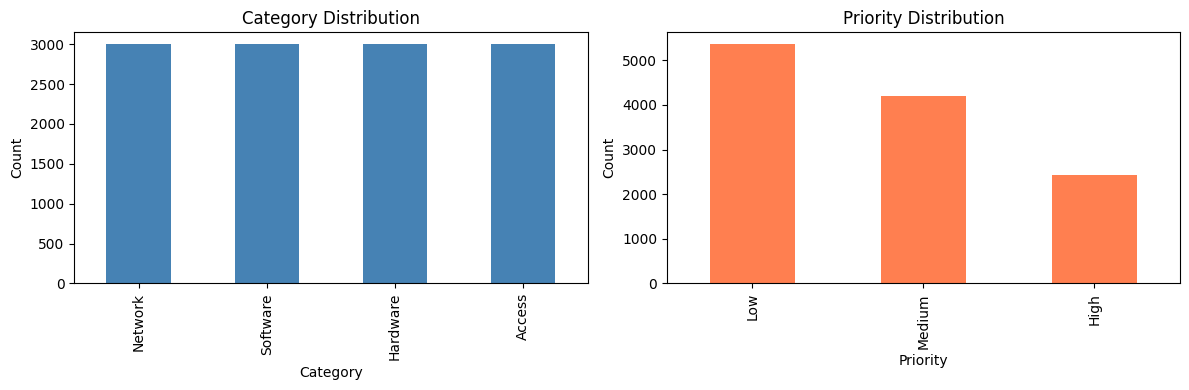

In [3]:
# Check class distribution
print("Category Distribution:")
print(df['category'].value_counts())
print("\nPriority Distribution:")
print(df['priority'].value_counts())

# Visualize distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df['category'].value_counts().plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Category Distribution')
axes[0].set_xlabel('Category')
axes[0].set_ylabel('Count')

df['priority'].value_counts().plot(kind='bar', ax=axes[1], color='coral')
axes[1].set_title('Priority Distribution')
axes[1].set_xlabel('Priority')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

## 2. Text Preprocessing

### 2.1 Cleaning Dasar
- Lowercase
- Remove punctuation
- Remove numbers
- Remove extra whitespace

In [4]:
def basic_cleaning(text):
    """
    Cleaning dasar:
    1. Lowercase
    2. Remove punctuation
    3. Remove numbers
    4. Remove extra whitespace
    """
    # Lowercase
    text = text.lower()
    
    # Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))
    
    # Remove numbers
    text = re.sub(r'\d+', '', text)
    
    # Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()
    
    return text

# Apply basic cleaning
df['cleaned_text'] = df['ticket_description'].apply(basic_cleaning)

# Show results
print("Before cleaning:")
print(df['ticket_description'].iloc[0])
print("\nAfter cleaning:")
print(df['cleaned_text'].iloc[0])

Before cleaning:
Network outage reported during peak working hours, this is a non-critical issue (ticket 0)

After cleaning:
network outage reported during peak working hours this is a noncritical issue ticket


### 2.2 Tokenization

In [5]:
def tokenize_text(text):
    """Tokenize text using NLTK word_tokenize"""
    return word_tokenize(text)

# Apply tokenization
df['tokenized'] = df['cleaned_text'].apply(tokenize_text)

# Show results
print("Cleaned text:")
print(df['cleaned_text'].iloc[0])
print("\nTokenized:")
print(df['tokenized'].iloc[0])

Cleaned text:
network outage reported during peak working hours this is a noncritical issue ticket

Tokenized:
['network', 'outage', 'reported', 'during', 'peak', 'working', 'hours', 'this', 'is', 'a', 'noncritical', 'issue', 'ticket']


### 2.3 Stopword Removal

In [6]:
# Initialize stopwords
stop_words = set(stopwords.words('english'))

def remove_stopwords(tokens):
    """Remove stopwords from tokenized text"""
    return [token for token in tokens if token not in stop_words]

# Apply stopword removal
df['no_stopwords'] = df['tokenized'].apply(remove_stopwords)

# Show results
print("Before stopword removal:")
print(df['tokenized'].iloc[0])
print("\nAfter stopword removal:")
print(df['no_stopwords'].iloc[0])
print(f"\nStopwords removed: {len(df['tokenized'].iloc[0]) - len(df['no_stopwords'].iloc[0])}")

Before stopword removal:
['network', 'outage', 'reported', 'during', 'peak', 'working', 'hours', 'this', 'is', 'a', 'noncritical', 'issue', 'ticket']

After stopword removal:
['network', 'outage', 'reported', 'peak', 'working', 'hours', 'noncritical', 'issue', 'ticket']

Stopwords removed: 4


### 2.4 Lemmatization

In [7]:
# Initialize lemmatizer
lemmatizer = WordNetLemmatizer()

def lemmatize_tokens(tokens):
    """Lemmatize tokens using WordNet Lemmatizer"""
    return [lemmatizer.lemmatize(token) for token in tokens]

# Apply lemmatization
df['lemmatized'] = df['no_stopwords'].apply(lemmatize_tokens)

# Join tokens back to text for model input
df['processed_text'] = df['lemmatized'].apply(lambda x: ' '.join(x))

# Show results
print("Before lemmatization:")
print(df['no_stopwords'].iloc[0])
print("\nAfter lemmatization:")
print(df['lemmatized'].iloc[0])
print("\nFinal processed text:")
print(df['processed_text'].iloc[0])

Before lemmatization:
['network', 'outage', 'reported', 'peak', 'working', 'hours', 'noncritical', 'issue', 'ticket']

After lemmatization:
['network', 'outage', 'reported', 'peak', 'working', 'hour', 'noncritical', 'issue', 'ticket']

Final processed text:
network outage reported peak working hour noncritical issue ticket


## 3. Label Encoding & Data Splitting

Split dataset: Train 70%, Validation 15%, Test 15%

In [8]:
# Encode labels - using priority as target
label_encoder = LabelEncoder()
df['label'] = label_encoder.fit_transform(df['priority'])

# Print label mapping
print("Label Mapping:")
for idx, label in enumerate(label_encoder.classes_):
    print(f"  {label} -> {idx}")
    
X = df['ticket_description'].values  # Gunakan teks asli!
y = df['label'].values

print(f"\nTotal samples: {len(X)}")
print(f"Number of classes: {len(label_encoder.classes_)}")

# Hitung class weights untuk mengatasi imbalance
from sklearn.utils.class_weight import compute_class_weight
class_weights = compute_class_weight('balanced', classes=np.unique(y), y=y)
class_weights_dict = {i: w for i, w in enumerate(class_weights)}
print(f"\nClass weights: {class_weights_dict}")

Label Mapping:
  High -> 0
  Low -> 1
  Medium -> 2

Total samples: 12000
Number of classes: 3

Class weights: {0: 1.6420361247947455, 1: 0.7461294534601753, 2: 0.9517011658339282}


In [9]:
# Split data: 70% train, 15% validation, 15% test
# First split: 70% train, 30% temp
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

# Second split: 50% of temp = 15% val, 15% test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

print("Data Split Summary:")
print(f"  Training set:   {len(X_train)} samples ({len(X_train)/len(X)*100:.1f}%)")
print(f"  Validation set: {len(X_val)} samples ({len(X_val)/len(X)*100:.1f}%)")
print(f"  Test set:       {len(X_test)} samples ({len(X_test)/len(X)*100:.1f}%)")

# Check class distribution in each split
print("\nClass distribution in splits:")
for name, labels in [("Train", y_train), ("Val", y_val), ("Test", y_test)]:
    unique, counts = np.unique(labels, return_counts=True)
    print(f"  {name}: {dict(zip(label_encoder.inverse_transform(unique), counts))}")

Data Split Summary:
  Training set:   8400 samples (70.0%)
  Validation set: 1800 samples (15.0%)
  Test set:       1800 samples (15.0%)

Class distribution in splits:
  Train: {'High': 1705, 'Low': 3753, 'Medium': 2942}
  Val: {'High': 365, 'Low': 804, 'Medium': 631}
  Test: {'High': 366, 'Low': 804, 'Medium': 630}


## 4. DistilBERT Dataset & Tokenizer Setup

In [10]:
# Load DistilBERT tokenizer
tokenizer = DistilBertTokenizer.from_pretrained('distilbert-base-uncased')

# Custom Dataset class for DistilBERT
class HelpdeskDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=128):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length
    
    def __len__(self):
        return len(self.texts)
    
    def __getitem__(self, idx):
        text = str(self.texts[idx])
        label = self.labels[idx]
        
        encoding = self.tokenizer.encode_plus(
            text,
            add_special_tokens=True,
            max_length=self.max_length,
            padding='max_length',
            truncation=True,
            return_attention_mask=True,
            return_tensors='pt'
        )
        
        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(label, dtype=torch.long)
        }

## 5. Grid Search for Hyperparameter Tuning

In [11]:
param_grid = {
    'learning_rate': [3e-5, 5e-5, 1e-4],  
    'batch_size': [8, 16],
    'epochs': [5, 8, 10],
    'max_length': [128] 
}

# Calculate total combinations
total_combinations = 1
for key, values in param_grid.items():
    total_combinations *= len(values)

print("Hyperparameter Grid:")
for key, values in param_grid.items():
    print(f"  {key}: {values}")
print(f"\nTotal combinations to try: {total_combinations}")

Hyperparameter Grid:
  learning_rate: [3e-05, 5e-05, 0.0001]
  batch_size: [8, 16]
  epochs: [5, 8, 10]
  max_length: [128]

Total combinations to try: 18


In [12]:
class_weights_tensor = torch.tensor(list(class_weights_dict.values()), dtype=torch.float).to(device)

def train_epoch(model, dataloader, optimizer, scheduler, device, class_weights=None):
    """Train model for one epoch with class weights"""
    model.train()
    total_loss = 0
    
    # Loss function dengan class weights
    loss_fn = torch.nn.CrossEntropyLoss(weight=class_weights) if class_weights is not None else None
    
    for batch in dataloader:
        optimizer.zero_grad()
        
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)
        
        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask
        )
        
        # Gunakan custom loss dengan class weights
        if loss_fn is not None:
            loss = loss_fn(outputs.logits, labels)
        else:
            outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
            loss = outputs.loss
            
        total_loss += loss.item()
        
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()
    
    return total_loss / len(dataloader)

def evaluate(model, dataloader, device):
    """Evaluate model on validation/test set"""
    model.eval()
    total_loss = 0
    predictions = []
    true_labels = []
    
    with torch.no_grad():
        for batch in dataloader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)
            
            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                labels=labels
            )
            
            total_loss += outputs.loss.item()
            
            preds = torch.argmax(outputs.logits, dim=1)
            predictions.extend(preds.cpu().numpy())
            true_labels.extend(labels.cpu().numpy())
    
    accuracy = accuracy_score(true_labels, predictions)
    return total_loss / len(dataloader), accuracy, predictions, true_labels

In [13]:
from itertools import product

def run_grid_search(X_train, y_train, X_val, y_val, param_grid, num_labels, device, class_weights):
    """Run grid search with class weights"""
    
    best_accuracy = 0
    best_params = None
    best_model_state = None
    results = []
    
    # Generate all combinations
    keys = list(param_grid.keys())
    combinations = list(product(*[param_grid[k] for k in keys]))
    
    print(f"Starting Grid Search with {len(combinations)} combinations...\n")
    
    for i, combo in enumerate(combinations):
        params = dict(zip(keys, combo))
        print(f"\n{'='*60}")
        print(f"Combination {i+1}/{len(combinations)}")
        print(f"Params: {params}")
        print('='*60)
        
        # Create datasets with current max_length
        train_dataset = HelpdeskDataset(X_train, y_train, tokenizer, params['max_length'])
        val_dataset = HelpdeskDataset(X_val, y_val, tokenizer, params['max_length'])
        
        # Create dataloaders with current batch_size
        train_loader = DataLoader(train_dataset, batch_size=params['batch_size'], shuffle=True)
        val_loader = DataLoader(val_dataset, batch_size=params['batch_size'])
        
        # Initialize fresh model
        model = DistilBertForSequenceClassification.from_pretrained(
            'distilbert-base-uncased',
            num_labels=num_labels
        )
        model.to(device)
        
        # Setup optimizer and scheduler
        optimizer = AdamW(model.parameters(), lr=params['learning_rate'], weight_decay=0.01)
        total_steps = len(train_loader) * params['epochs']
        scheduler = get_linear_schedule_with_warmup(
            optimizer,
            num_warmup_steps=int(0.1 * total_steps),  # 10% warmup
            num_training_steps=total_steps
        )
        
        # Training loop dengan class weights
        for epoch in range(params['epochs']):
            train_loss = train_epoch(model, train_loader, optimizer, scheduler, device, class_weights)
            val_loss, val_accuracy, _, _ = evaluate(model, val_loader, device)
            print(f"  Epoch {epoch+1}/{params['epochs']} - Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}, Val Acc: {val_accuracy:.4f}")
        
        # Final validation
        _, final_accuracy, _, _ = evaluate(model, val_loader, device)
        
        # Store results
        results.append({
            **params,
            'val_accuracy': final_accuracy
        })
        
        # Update best model
        if final_accuracy > best_accuracy:
            best_accuracy = final_accuracy
            best_params = params.copy()
            best_model_state = model.state_dict().copy()
            print(f"New best model! Accuracy: {best_accuracy:.4f}")
        
        # Clear memory
        del model
        torch.cuda.empty_cache() if torch.cuda.is_available() else None
    
    return best_params, best_accuracy, best_model_state, results

In [14]:
# Run Grid Search dengan class weights
num_labels = len(label_encoder.classes_)

best_params, best_accuracy, best_model_state, grid_results = run_grid_search(
    X_train, y_train, X_val, y_val, param_grid, num_labels, device, class_weights_tensor
)

print("GRID SEARCH COMPLETED!")
print(f"\nBest Parameters:")
for key, value in best_params.items():
    print(f"  {key}: {value}")
print(f"\nBest Validation Accuracy: {best_accuracy:.4f}")

Starting Grid Search with 18 combinations...


Combination 1/18
Params: {'learning_rate': 3e-05, 'batch_size': 8, 'epochs': 5, 'max_length': 128}


Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


  Epoch 1/5 - Train Loss: 0.1417, Val Loss: 0.0001, Val Acc: 1.0000
  Epoch 2/5 - Train Loss: 0.0015, Val Loss: 0.0000, Val Acc: 1.0000
  Epoch 3/5 - Train Loss: 0.0000, Val Loss: 0.0000, Val Acc: 1.0000
  Epoch 4/5 - Train Loss: 0.0000, Val Loss: 0.0000, Val Acc: 1.0000
  Epoch 5/5 - Train Loss: 0.0000, Val Loss: 0.0000, Val Acc: 1.0000
  ★ New best model! Accuracy: 1.0000

Combination 2/18
Params: {'learning_rate': 3e-05, 'batch_size': 8, 'epochs': 8, 'max_length': 128}


Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


  Epoch 1/8 - Train Loss: 0.1809, Val Loss: 0.0002, Val Acc: 1.0000
  Epoch 2/8 - Train Loss: 0.0001, Val Loss: 0.0000, Val Acc: 1.0000
  Epoch 3/8 - Train Loss: 0.0000, Val Loss: 0.0000, Val Acc: 1.0000
  Epoch 4/8 - Train Loss: 0.0006, Val Loss: 0.0000, Val Acc: 1.0000
  Epoch 5/8 - Train Loss: 0.0000, Val Loss: 0.0000, Val Acc: 1.0000
  Epoch 6/8 - Train Loss: 0.0000, Val Loss: 0.0000, Val Acc: 1.0000
  Epoch 7/8 - Train Loss: 0.0000, Val Loss: 0.0000, Val Acc: 1.0000
  Epoch 8/8 - Train Loss: 0.0000, Val Loss: 0.0000, Val Acc: 1.0000

Combination 3/18
Params: {'learning_rate': 3e-05, 'batch_size': 8, 'epochs': 10, 'max_length': 128}


...

  Epoch 1/5 - Train Loss: 0.1188, Val Loss: 0.0000, Val Acc: 1.0000
  Epoch 2/5 - Train Loss: 0.0000, Val Loss: 0.0000, Val Acc: 1.0000
  Epoch 3/5 - Train Loss: 0.0000, Val Loss: 0.0000, Val Acc: 1.0000
  Epoch 4/5 - Train Loss: 0.0000, Val Loss: 0.0000, Val Acc: 1.0000
  Epoch 5/5 - Train Loss: 0.0000, Val Loss: 0.0000, Val Acc: 1.0000

Combination 17/18
Params: {'learning_rate': 0.0001, 'batch_size': 16, 'epochs': 8, 'max_length': 128}


Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


  Epoch 1/8 - Train Loss: 0.1512, Val Loss: 0.0001, Val Acc: 1.0000
  Epoch 2/8 - Train Loss: 0.0000, Val Loss: 0.0000, Val Acc: 1.0000
  Epoch 3/8 - Train Loss: 0.0000, Val Loss: 0.0000, Val Acc: 1.0000
  Epoch 4/8 - Train Loss: 0.0000, Val Loss: 0.0000, Val Acc: 1.0000
  Epoch 5/8 - Train Loss: 0.0000, Val Loss: 0.0000, Val Acc: 1.0000
  Epoch 6/8 - Train Loss: 0.0000, Val Loss: 0.0000, Val Acc: 1.0000
  Epoch 7/8 - Train Loss: 0.0000, Val Loss: 0.0000, Val Acc: 1.0000
  Epoch 8/8 - Train Loss: 0.0000, Val Loss: 0.0000, Val Acc: 1.0000

Combination 18/18
Params: {'learning_rate': 0.0001, 'batch_size': 16, 'epochs': 10, 'max_length': 128}


Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


  Epoch 1/10 - Train Loss: 0.1629, Val Loss: 0.0001, Val Acc: 1.0000
  Epoch 2/10 - Train Loss: 0.0001, Val Loss: 0.0000, Val Acc: 1.0000
  Epoch 3/10 - Train Loss: 0.0000, Val Loss: 0.0000, Val Acc: 1.0000
  Epoch 4/10 - Train Loss: 0.0000, Val Loss: 0.0000, Val Acc: 1.0000
  Epoch 5/10 - Train Loss: 0.0000, Val Loss: 0.0000, Val Acc: 1.0000
  Epoch 6/10 - Train Loss: 0.0000, Val Loss: 0.0000, Val Acc: 1.0000
  Epoch 7/10 - Train Loss: 0.0000, Val Loss: 0.0000, Val Acc: 1.0000
  Epoch 8/10 - Train Loss: 0.0000, Val Loss: 0.0000, Val Acc: 1.0000
  Epoch 9/10 - Train Loss: 0.0000, Val Loss: 0.0000, Val Acc: 1.0000
  Epoch 10/10 - Train Loss: 0.0000, Val Loss: 0.0000, Val Acc: 1.0000
GRID SEARCH COMPLETED!

Best Parameters:
  learning_rate: 3e-05
  batch_size: 8
  epochs: 5
  max_length: 128

Best Validation Accuracy: 1.0000


In [15]:
# Display Grid Search Results
results_df = pd.DataFrame(grid_results)
results_df = results_df.sort_values('val_accuracy', ascending=False)

print("Grid Search Results (sorted by validation accuracy):")
print(results_df.to_string(index=False))

Grid Search Results (sorted by validation accuracy):
 learning_rate  batch_size  epochs  max_length  val_accuracy
       0.00003           8       5         128           1.0
       0.00003           8       8         128           1.0
       0.00010          16       8         128           1.0
       0.00010          16       5         128           1.0
       0.00010           8      10         128           1.0
       0.00010           8       8         128           1.0
       0.00010           8       5         128           1.0
       0.00005          16      10         128           1.0
       0.00005          16       8         128           1.0
       0.00005          16       5         128           1.0
       0.00005           8      10         128           1.0
       0.00005           8       8         128           1.0
       0.00005           8       5         128           1.0
       0.00003          16      10         128           1.0
       0.00003          16      

## 6. Train Final Model with Best Parameters

In [16]:
# Load best model with best parameters
final_model = DistilBertForSequenceClassification.from_pretrained(
    'distilbert-base-uncased',
    num_labels=num_labels
)
final_model.load_state_dict(best_model_state)
final_model.to(device)

print("Final model loaded with best parameters!")
print(f"Best params: {best_params}")

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Final model loaded with best parameters!
Best params: {'learning_rate': 3e-05, 'batch_size': 8, 'epochs': 5, 'max_length': 128}


## 7. Evaluasi Model pada Test Set

In [17]:
# Create test dataset with best max_length
test_dataset = HelpdeskDataset(X_test, y_test, tokenizer, best_params['max_length'])
test_loader = DataLoader(test_dataset, batch_size=best_params['batch_size'])

# Evaluate on test set
test_loss, test_accuracy, y_pred, y_true = evaluate(final_model, test_loader, device)

In [18]:
# Calculate metrics
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average='weighted')
recall = recall_score(y_true, y_pred, average='weighted')
f1 = f1_score(y_true, y_pred, average='weighted')

print("EVALUATION METRICS")
print(f"\n{'Metric':<20} {'Score':>10}")
print("-"*30)
print(f"{'Accuracy':<20} {accuracy:>10.4f}")
print(f"{'Precision (weighted)':<20} {precision:>10.4f}")
print(f"{'Recall (weighted)':<20} {recall:>10.4f}")
print(f"{'F1-Score (weighted)':<20} {f1:>10.4f}")
print("-"*30)

EVALUATION METRICS

Metric                    Score
------------------------------
Accuracy                 1.0000
Precision (weighted)     1.0000
Recall (weighted)        1.0000
F1-Score (weighted)      1.0000
------------------------------


In [19]:
# Classification Report
print("\nClassification Report:")
print("="*60)
print(classification_report(y_true, y_pred, target_names=label_encoder.classes_))


Classification Report:
              precision    recall  f1-score   support

        High       1.00      1.00      1.00       366
         Low       1.00      1.00      1.00       804
      Medium       1.00      1.00      1.00       630

    accuracy                           1.00      1800
   macro avg       1.00      1.00      1.00      1800
weighted avg       1.00      1.00      1.00      1800



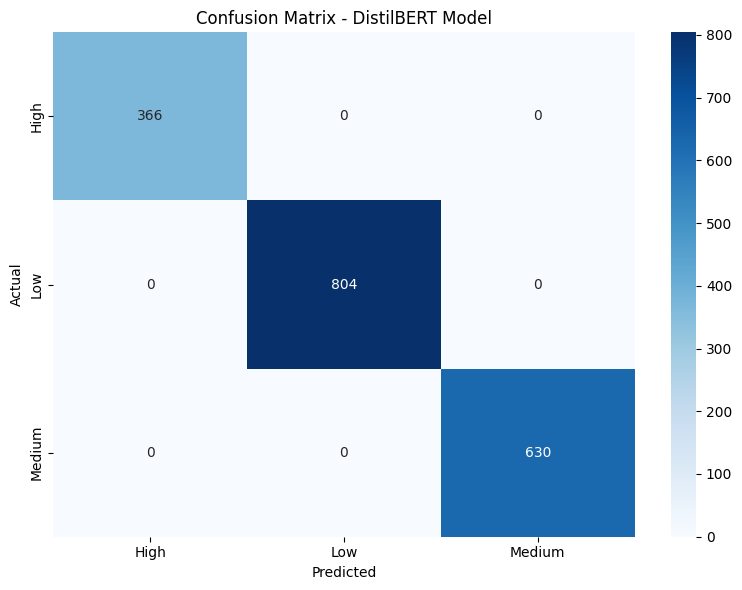


Confusion Matrix Values:
[[366   0   0]
 [  0 804   0]
 [  0   0 630]]


In [20]:
# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=label_encoder.classes_, 
            yticklabels=label_encoder.classes_)
plt.title('Confusion Matrix - DistilBERT Model')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

print("\nConfusion Matrix Values:")
print(cm)

In [21]:
# Retrain best model while tracking metrics for overfitting/underfitting analysis
print("Retraining best model to track learning curves...")
print(f"Best params: {best_params}\n")

# Create datasets
train_dataset = HelpdeskDataset(X_train, y_train, tokenizer, best_params['max_length'])
val_dataset = HelpdeskDataset(X_val, y_val, tokenizer, best_params['max_length'])

train_loader = DataLoader(train_dataset, batch_size=best_params['batch_size'], shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=best_params['batch_size'])

# Initialize fresh model
tracking_model = DistilBertForSequenceClassification.from_pretrained(
    'distilbert-base-uncased',
    num_labels=num_labels
)
tracking_model.to(device)

# Setup optimizer and scheduler
optimizer = AdamW(tracking_model.parameters(), lr=best_params['learning_rate'], weight_decay=0.01)
total_steps = len(train_loader) * best_params['epochs']
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=int(0.1 * total_steps),
    num_training_steps=total_steps
)

# Track metrics per epoch
history = {
    'train_loss': [],
    'val_loss': [],
    'train_accuracy': [],
    'val_accuracy': []
}

def evaluate_with_accuracy(model, dataloader, device, class_weights=None):
    """Evaluate and return loss and accuracy"""
    model.eval()
    total_loss = 0
    predictions = []
    true_labels = []
    
    loss_fn = torch.nn.CrossEntropyLoss(weight=class_weights) if class_weights is not None else torch.nn.CrossEntropyLoss()
    
    with torch.no_grad():
        for batch in dataloader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)
            
            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            loss = loss_fn(outputs.logits, labels)
            total_loss += loss.item()
            
            preds = torch.argmax(outputs.logits, dim=1)
            predictions.extend(preds.cpu().numpy())
            true_labels.extend(labels.cpu().numpy())
    
    accuracy = accuracy_score(true_labels, predictions)
    return total_loss / len(dataloader), accuracy

# Training loop with tracking
for epoch in range(best_params['epochs']):
    # Training
    tracking_model.train()
    train_loss = train_epoch(tracking_model, train_loader, optimizer, scheduler, device, class_weights_tensor)
    
    # Evaluate on train set
    train_loss_eval, train_acc = evaluate_with_accuracy(tracking_model, train_loader, device, class_weights_tensor)
    
    # Evaluate on validation set
    val_loss, val_acc = evaluate_with_accuracy(tracking_model, val_loader, device, class_weights_tensor)
    
    # Store metrics
    history['train_loss'].append(train_loss_eval)
    history['val_loss'].append(val_loss)
    history['train_accuracy'].append(train_acc)
    history['val_accuracy'].append(val_acc)
    
    print(f"Epoch {epoch+1}/{best_params['epochs']}")
    print(f"  Train Loss: {train_loss_eval:.4f}, Train Acc: {train_acc:.4f}")
    print(f"  Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")
    print(f"  Gap (Train-Val Acc): {train_acc - val_acc:.4f}")
    print()

# Clean up
del tracking_model
torch.cuda.empty_cache() if torch.cuda.is_available() else None

Retraining best model to track learning curves...
Best params: {'learning_rate': 3e-05, 'batch_size': 8, 'epochs': 5, 'max_length': 128}



Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch 1/5
  Train Loss: 0.0001, Train Acc: 1.0000
  Val Loss: 0.0001, Val Acc: 1.0000
  Gap (Train-Val Acc): 0.0000

Epoch 2/5
  Train Loss: 0.0000, Train Acc: 1.0000
  Val Loss: 0.0000, Val Acc: 1.0000
  Gap (Train-Val Acc): 0.0000

Epoch 3/5
  Train Loss: 0.0000, Train Acc: 1.0000
  Val Loss: 0.0000, Val Acc: 1.0000
  Gap (Train-Val Acc): 0.0000

Epoch 4/5
  Train Loss: 0.0000, Train Acc: 1.0000
  Val Loss: 0.0000, Val Acc: 1.0000
  Gap (Train-Val Acc): 0.0000

Epoch 5/5
  Train Loss: 0.0000, Train Acc: 1.0000
  Val Loss: 0.0000, Val Acc: 1.0000
  Gap (Train-Val Acc): 0.0000



## 8. Simpan Best Model ke Folder Weight

In [25]:
import os

# Create weight folder if not exists
weight_path = '../weight'
os.makedirs(weight_path, exist_ok=True)

# Save model state dict as best.pt
model_save_path = os.path.join(weight_path, 'best.pt')

# Save complete model checkpoint
checkpoint = {
    'model_state_dict': final_model.state_dict(),
    'best_params': best_params,
    'label_encoder_classes': label_encoder.classes_.tolist(),
    'num_labels': num_labels,
    'metrics': {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1_score': f1
    }
}

torch.save(checkpoint, model_save_path)
print(f"Model saved successfully to: {model_save_path}")
print(f"\nSaved checkpoint contains:")
print(f" - model_state_dict")
print(f" - best_params: {best_params}")
print(f" - label_encoder_classes: {label_encoder.classes_.tolist()}")
print(f" - num_labels: {num_labels}")
print(f" - metrics: accuracy={accuracy:.4f}, precision={precision:.4f}, recall={recall:.4f}, f1={f1:.4f}")

Model saved successfully to: ../weight\best.pt

Saved checkpoint contains:
 - model_state_dict
 - best_params: {'learning_rate': 3e-05, 'batch_size': 8, 'epochs': 5, 'max_length': 128}
 - label_encoder_classes: ['High', 'Low', 'Medium']
 - num_labels: 3
 - metrics: accuracy=1.0000, precision=1.0000, recall=1.0000, f1=1.0000


## 9. Inference Function (Load & Predict)

In [27]:
def load_model_and_predict(text, model_path='../weight/best.pt'):
    """
    Load saved model and make predictions
    """
    # Load checkpoint
    checkpoint = torch.load(model_path, map_location=device)
    
    # Initialize model
    model = DistilBertForSequenceClassification.from_pretrained(
        'distilbert-base-uncased',
        num_labels=checkpoint['num_labels']
    )
    model.load_state_dict(checkpoint['model_state_dict'])
    model.to(device)
    model.eval()
    
    # Tokenize input
    tokenizer = DistilBertTokenizer.from_pretrained('distilbert-base-uncased')
    encoding = tokenizer.encode_plus(
        text,
        add_special_tokens=True,
        max_length=checkpoint['best_params']['max_length'],
        padding='max_length',
        truncation=True,
        return_attention_mask=True,
        return_tensors='pt'
    )
    
    # Predict
    with torch.no_grad():
        input_ids = encoding['input_ids'].to(device)
        attention_mask = encoding['attention_mask'].to(device)
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        prediction = torch.argmax(outputs.logits, dim=1).item()
    
    # Map to label
    label_classes = checkpoint['label_encoder_classes']
    predicted_label = label_classes[prediction]
    
    return predicted_label

# Test inference
test_texts = [
    "Internet connection is very slow",
    "VPN keeps disconnecting frequently",
    "Network latency is high during meetings"
]

print("Testing Inference:")

for text in test_texts:
    prediction = load_model_and_predict(text)
    print(f"Text: '{text}'")
    print(f"Predicted Priority: {prediction}\n")

Testing Inference:


Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Text: 'Internet connection is very slow'
Predicted Priority: High



Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Text: 'VPN keeps disconnecting frequently'
Predicted Priority: High



Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Text: 'Network latency is high during meetings'
Predicted Priority: High

